## **Modelos Unimodales en Validación**

Para cada uno de los codificadores por cada modalidad, se definen y entrenan clasificadores independientes para el **corpus global**, primero empleando hiperparámetros derivados del **EDA** y la literatura evaluando los modelos resultantes en validación, para la posterior selección de extractores de características que mayor rendimiento conjunto logran. 

**El notebook se estructura de la siguiente manera:**
1. **Definición de las Clases Unimodales (Dataset)**: En PyTorch, es necesario que, para la carga de datos (labels y embeddings), se debe crear una clase que herede de `torch.utils.data.Dataset`, que esta es la encargada de, indicando la ruta donde se encuentran estos datos, cargarlos debidamente y devolver el tensor (embedding) y la etiqueta (label) asociada a dicha muestra. Se define una clase por cada modalidad por separado para cargar los datos individualmente y que el posterior DataLoader devuelva los datos por cada modalidad específica. 
2. **Clasificador Unimodal**: Se crea el clasificador detallando la estructura (que debe ser similar a la estructura del clasificador definido tras aplicar las estrategias de fusión, y así permitir la comparación justa).
3. **Definición de la Función de Entrenamiento**: Se crea la función encargada del entrenamiento del modelo unimodal, la cual primero instanciará el adaptador de la modalidad, llevará a cabo el entrenamiento iterando a nivel de *epoch*/*batch*, y tras cada *epoch*, evaluará en validación el rendimiento del modelo (*forward-pass*) controlando mediante *early-stopping* el sobreajuste.
4. **Bucle de Ejecución**: Celda de código en donde se cargan los datos y se ejecuta el entrenamiento de los modelos unimodales **fijando primeramente hiperparámetros estándar**.
5. **Definición de la Función de Evaluación**: Esta función se encargará de evaluar con las métricas clave de nuestro proyecto, en la partición de validación o en la de test según lo que se indique a la entrada, a los modelos unimodales.
6. **Resultados de Evaluación en Validación (dev)**: Se muestra por cada modelo unimodal los resultados obtenidos para la partición de validación.


**Una vez tenemos los resultados de los baselines unimodales para validación (dev), estos se tendrán en cuenta para la selección de extractores de características en el siguiente **notebook**, fijando los mismos hiperparámetros estándar utilizados y arquitectura similar, permitiendo la comparación, y evitando la explosión de hiperparámetros y la fuga de datos, realizando la selección desde validación**. 

In [1]:
# Importación de las librerías
import os
import torch
import pandas as pd
from IPython.display import display


import subprocess
import json
from IPython.display import Image, display

# Configuración del dispositivo:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entorno de ejecución configurado en: {device}")

Entorno de ejecución configurado en: cuda


### **1. Clases Unimodales (Dataset) para la carga de datos**:

Para que PyTorch pueda leer los embeddings de cada una de las modalidades, debemos crear una clase que herede de `torch.utils.data.Dataset`, y debemos implementar los métodos `__len__` y `__getitem__`, además del constructor. Esta clase que carga los datos (embeddings) preprocesados se encuentra ya definida en `dataset.py`. 

### **2. Arquitectura Clasificador Unimodal**

Para una comparación justa con las posteriores estrategias de fusión, esta arquitectura cuenta con **3 partes**, imitando las arquitecturas multimodales que construiremos a continuación:

1. **Extractor de Características**: Modelo preentrenado que actúa como extractor de características de la arquitectura, por cada modalidad. 

2. **Adaptador**: Toma las representaciones densas (*embeddings*) del extractor de características y las proyecta a un espacio latente (`proj_dim`) común (normalizado con media 0 y desviación 1). Esto también estará presente para las posteriores estrategias *early*, *late* y *attention fusion*. 

3. **Clasificador MLP**: Se define un clasificador unimodal genérico constituido por dos capas lineales que comprimen la representación de `proj_dim` dimensiones inicial (que toma el adaptador correspondiente de la modalidad) a `hidden_mlp` dimensiones, que finalmente se reduce a una única salida final en bruto (logit). Esta cuenta con capas de dropout y ReLU para evitar el sobreajuste y aplicar no linealidad, respectivamente. 

    * **Estructura**:
        - Capa Lineal(`proj_dim`, `hidden_mlp`): Reducción de la dimensionalidad de 512 (`proj_dim`) -> 128 (`hidden_mlp`) según valores predeterminados,
        - BatchNormal1d(`hidden_mlp`): Normalización por lotes.
        - ReLU(): Capa no lineal, establecemos a 0 los valores negativos,
        - Dropout(`dropout_prob`): Evitamos sobreajuste,
        - Capa Lineal(`hidden_mlp`,1): Reducción de 128 (valor predeterminado) a 1 (salida).
    Debido a la naturaleza desbalanceada del dataset, para una mayor robustez, se aplica la función de pérdida `BCEWithLogitsLoss` porque es más estable. Esto se mantendrá para las posteriores estrategias de fusión.

Este clasificador se encuentra definido en `unimodal_classifier.py`. 

### **3. Función de Entrenamiento**

**Hiperparámetros fijados**:

- **Configuración de la arquitectura**: Valores fijados teniendo en cuenta los valores respaldados por la literatura y las dimensiones de los vectores de entrada.

    * `proj_dim`= 512 (valor predeterminado). Las dimensiones del espacio latente común de las modalidades será de 512.
    * `hidden_mlp`= 128 (valor predeterminado). Este valor indica las dimensiones del espacio latente proyectado por la primera capa del Clasificador MLP, para comprimir las características iniciales recibidas. 

- **Entrenamiento y Regularización**: Parámetros fijados de acuerdo a la literatura.

    * `dropout`= 0.5 (valor predeterminado)
    * `weight_decay`= 1e-2 (valor predeterminado)
    * `epochs`= 20 (valor predeterminado)
    * `patience`= 5 (valor predeterminado)
    * `pos_weight_mult`= 1.0 (valor predeterminado). Este valor es el multiplicador para el peso de la clase positiva, a mayor valor hacemos que el modelo reciba mayor penalización cuando falla en la clase positiva (estrés).

- **Gestión del Desbalanceo**:
    - `BCEWithLogitsLoss` + `pos_weight`: Esta función de pérdida integra una capa Sigmoide junto con la pérdida de entropía cruzada binaria clásica (*Binary Cross-Entropy*). Gracias a ella, se permite introducir un parámetro de entrada (`pos_weight`) para aplicar una penalización extra cuando el modelo falla en la clase minoritaria (estrés). Para abordar este desbalanceo, gracias a `pos_weight`, se aplica una técnica llamada *Cost-Sensitive Learning*, donde se calcula este peso positivo como ratio entre el número de muestras negativas y positivas (**num_negativos/num_positivos**) fijado en train. Para validación y test aplicamos este mismo valor, y así evitamos la fuga de datos. Este parámetro es una constante global para las distintas particiones/modalidades/batches, toma un único valor constante calculado con train. Al incorporar este coeficiente a la función de pérdida, la red penaliza mucho más los errores de clasificación cometidos en la clase minoritaria. Esto es una práctica estándar en el tratamiento de datasets desbalanceados en Machine Learning. 

- **Regularización y Optimizador**:

    - `AdamW` con `weight_decay=1e-2`: Variante superior a `Adam` clásico, ya que `Adam` es mucho más propenso a sobreajuste para datasets medianos o pequeños (ya que *weight decay* no es independiente del gradiente). Según demuestran Loshchilov y Hutter en su trabajo *Decoupled Weight Decay Regularization*, `AdamW` desacopla el decaimiento de los pesos (*weight decay*) del cálculo de los gradientes adaptativos. Se fija un **weight_decay = 1e-2**, lo que introduce una penalización L2 que restringe el crecimiento excesivo de los pesos. Garantizamos así una mayor generalización del modelo. 

    - `Learning Rate`(**1e-4**): Estándar en la literatura.

- **Ciclo de Entrenamiento**:

    - **Epochs** `20` y **Batch Size** `32`: Equilibrio entre estabilidad del gradiente y consumo de memoria. Fijamos pocas épocas ya que enfoques basados en *embeddings* preentrenados tienden a converger rápidamente. 

    - **Early Stopping (Paciencia = 5)**: Para evitar el sobreajuste, se implementa el mecanismo de parada temprana con una paciencia de 5 épocas. El criterio de monitorización no es la exactitud (*accuracy*) sino el **F1-Score Macro**, que es nuestra principal métrica debido al desbalanceo del dataset. 

- **Tamaño Ventanas**:

    - Fijamos las ventanas extraídas en las conclusiones del EDA:
        - **Video**: **32 frames**.
        - **Audio**: **11 segundos** (550 pasos).
        - **Texto**: **64 tokens**.

Este entrenamiento queda definido en `train.py`. 

### **4. Bucle de Ejecución**

In [37]:
# BACKBONES de cada modalidad: 

# ---VÍDEO ---

backbones_video = ['resnet','vit','efficientnet']
for backbone in backbones_video:
    comando = (
        f"python train.py "
        f"--video {backbone} "
        f"--video_frames 32 "
    )

    _ = subprocess.run(comando, shell=True)
    
# --- AUDIO ---
backbones_audio = ['wav2vec','mfcc']
for backbone in backbones_audio:
    comando = (
        f"python train.py "
        f"--audio {backbone} "
        f"--audio_len 11 "
    )

    _ = subprocess.run(comando, shell=True)

# --- TEXTO---
backbones_texto_64 = ['bert64','roberta64','deberta64']
for backbone in backbones_texto_64:
    comando = (
        f"python train.py "
        f"--text {backbone} "
    )

    _ = subprocess.run(comando, shell=True)


ENTRENAMIENTO BASELINE:
Modalidad: VIDEO
Backbone: RESNET


Epoch 1/20: 100%|██████████| 453/453 [00:07<00:00, 64.13it/s, loss=1.05] 


Epoch 1. Train Loss: 0.9869. Val Loss: 1.0977. Val F1 Macro: 0.5447. Val Recall Estrés: 0.7179

Nuevo mejor modelo: (F1: 0.5447) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:06<00:00, 72.32it/s, loss=1.61] 


Epoch 2. Train Loss: 0.9518. Val Loss: 1.1230. Val F1 Macro: 0.5638. Val Recall Estrés: 0.6471

Nuevo mejor modelo: (F1: 0.5638) -> Guardando pesos...


...

Epoch 10. Train Loss: 0.8746. Val Loss: 0.9242. Val F1 Macro: 0.6488. Val Recall Estrés: 0.7496

Sin mejora en F1-Score. Límite: 3/5


Epoch 11/20: 100%|██████████| 453/453 [00:02<00:00, 171.13it/s, loss=1.12] 


Epoch 11. Train Loss: 0.8570. Val Loss: 0.9193. Val F1 Macro: 0.6258. Val Recall Estrés: 0.8024

Sin mejora en F1-Score. Límite: 4/5


Epoch 12/20: 100%|██████████| 453/453 [00:02<00:00, 170.45it/s, loss=1.07] 


Epoch 12. Train Loss: 0.8577. Val Loss: 0.9132. Val F1 Macro: 0.6560. Val Recall Estrés: 0.7738

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 12 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_baseline_unimodal_texto_deberta64_ventana64_pdim512_hmlp128_do0.5_lr0.0001.pth
Historial de entrenamiento guardado en: ./historial_pesos_baseline_unimodal_texto_deberta64_ventana64_pdim512_hmlp128_do0.5_lr0.0001.json


### **5. Definición Función de Evaluación**

Esta se encuentra definida en `evaluate.py`, misma evaluación que se realizará para las arquitecturas multimodales (estableciendo como principales métricas F1-Score Macro, Recall para Estrés, ROC-AUC, Balanced Accuracy).

### **6. Resultados Baselines Unimodales** (Validación)

* **CODIFICADORES VISUALES** (Ventanas fijadas de 32 *frames*):
* `ResNet50`

100%|██████████| 2478/2478 [00:03<00:00, 755.58it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 5,577,729
Parámetros Entrenables: 5,577,729
Tiempo medio de Inferencia: 0.71 ms / muestra
ROC-AUC Score: 0.6131
F1 Macro: 0.5658
F1 Weighted: 0.6146
Accuracy (en %): 59.12%
Balanced Accuracy (en %): 61.08%


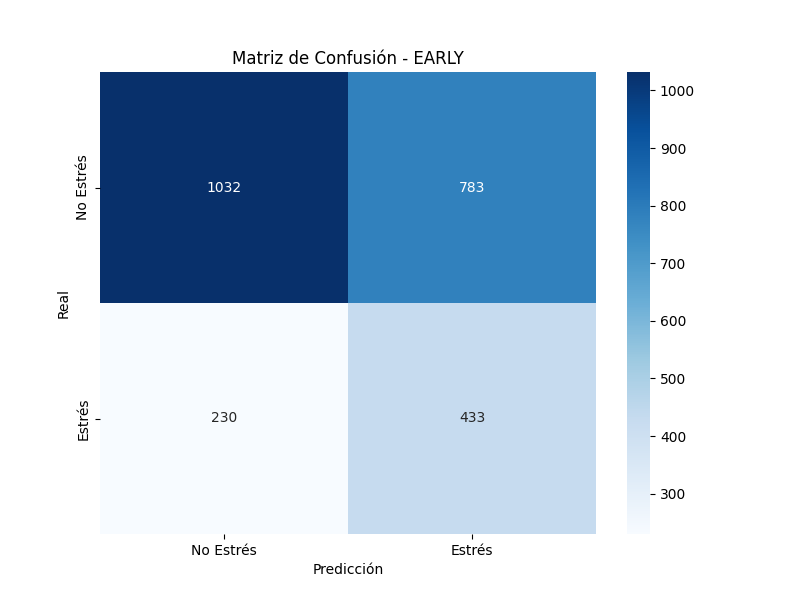

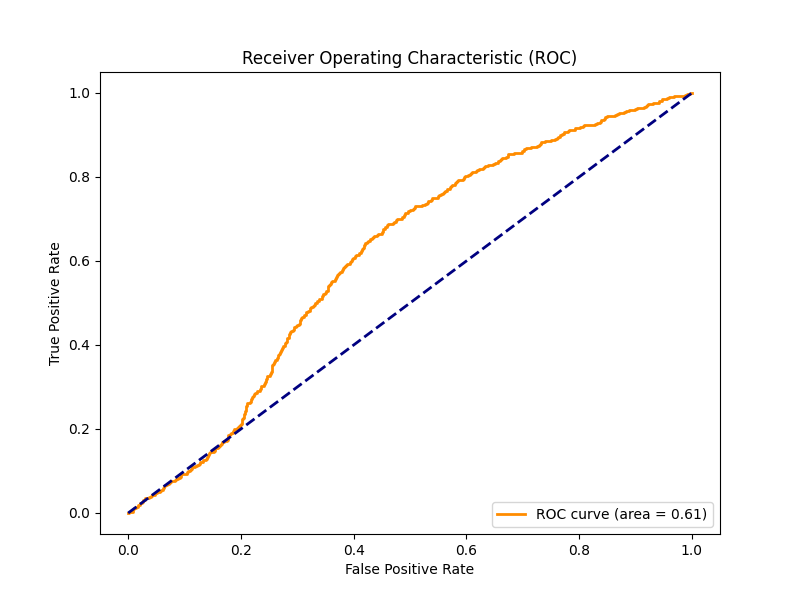

In [3]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_video_resnet_ventana32_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--video resnet "
        f"--video_frames 32 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_VIDEO_resnet_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_VIDEO_resnet_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* `EfficientNet-B0`

100%|██████████| 2478/2478 [00:03<00:00, 696.75it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 4,004,865
Parámetros Entrenables: 4,004,865
Tiempo medio de Inferencia: 0.79 ms / muestra
ROC-AUC Score: 0.6121
F1 Macro: 0.5715
F1 Weighted: 0.6313
Accuracy (en %): 61.02%
Balanced Accuracy (en %): 60.03%


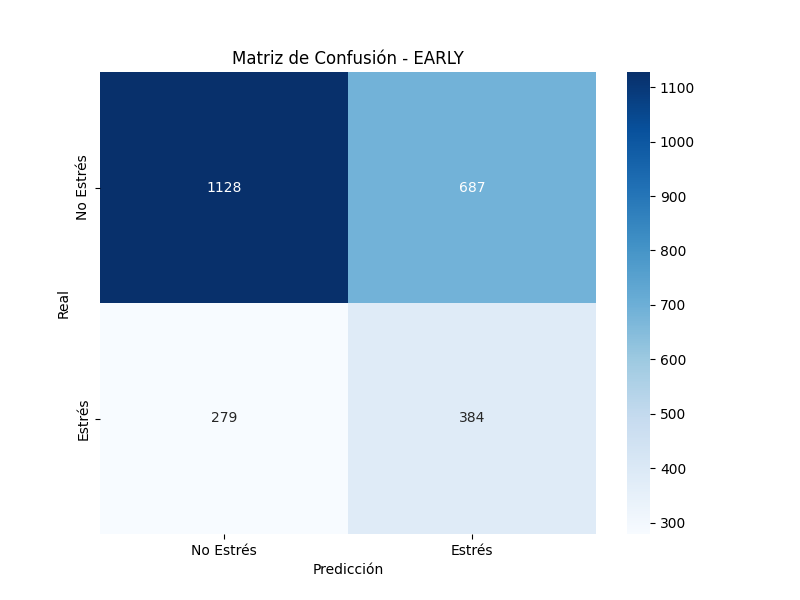

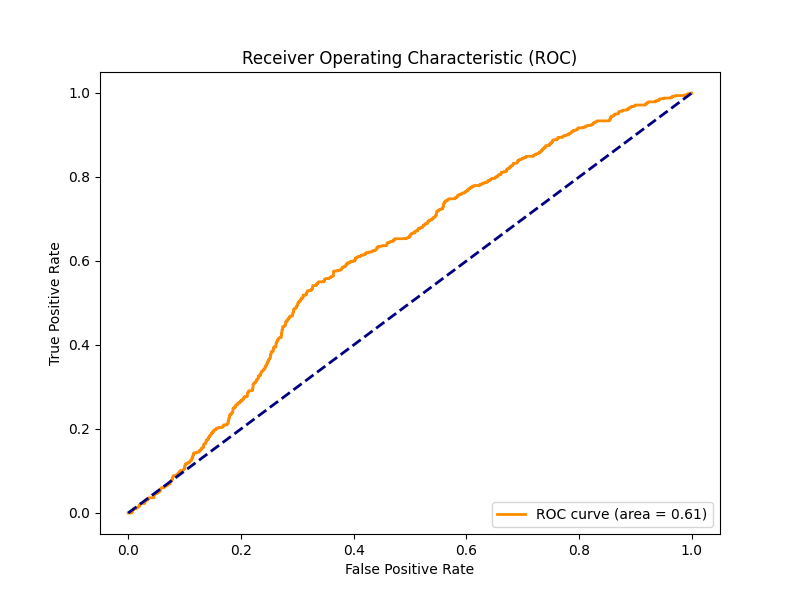

In [4]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_video_efficientnet_ventana32_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--video efficientnet "
        f"--video_frames 32 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_VIDEO_efficientnet_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_VIDEO_efficientnet_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* `ViT`

100%|██████████| 2478/2478 [00:02<00:00, 1045.26it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 2,956,289
Parámetros Entrenables: 2,956,289
Tiempo medio de Inferencia: 0.53 ms / muestra
ROC-AUC Score: 0.6130
F1 Macro: 0.5402
F1 Weighted: 0.5762
Accuracy (en %): 55.33%
Balanced Accuracy (en %): 60.60%


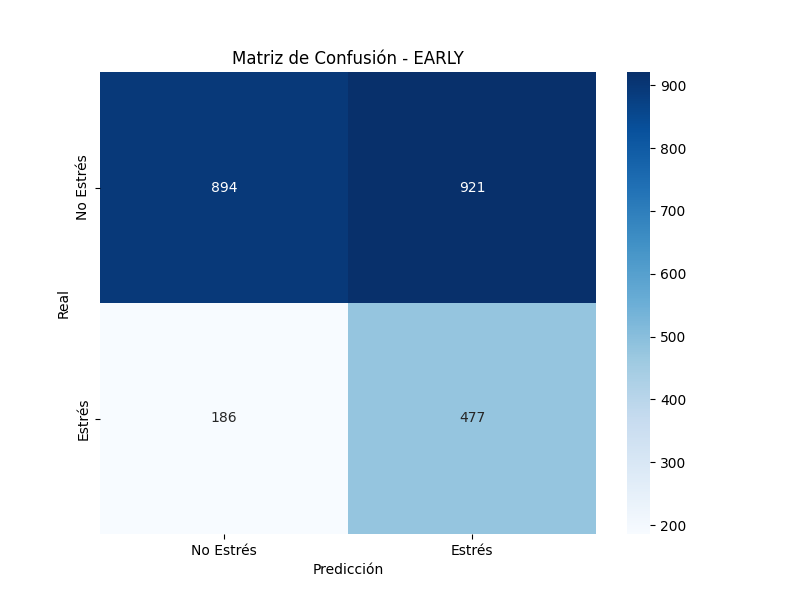

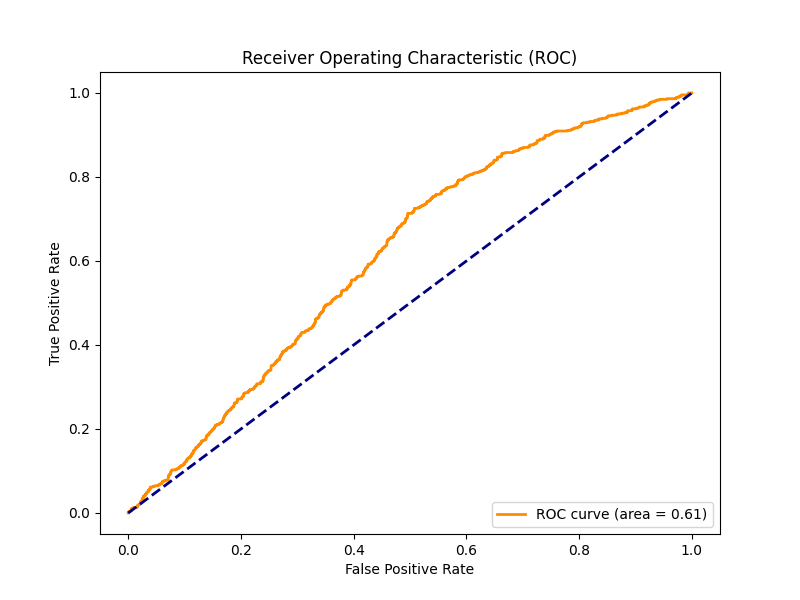

In [5]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_video_vit_ventana32_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--video vit "
        f"--video_frames 32 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_VIDEO_vit_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_VIDEO_vit_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **CODIFICADORES ACÚSTICOS** (Ventanas fijadas de 11s):

* `Wav2Vec 2.0`

100%|██████████| 2478/2478 [00:13<00:00, 185.11it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 2,956,289
Parámetros Entrenables: 2,956,289
Tiempo medio de Inferencia: 4.31 ms / muestra
ROC-AUC Score: 0.6964
F1 Macro: 0.6006
F1 Weighted: 0.6422
Accuracy (en %): 62.07%
Balanced Accuracy (en %): 65.87%


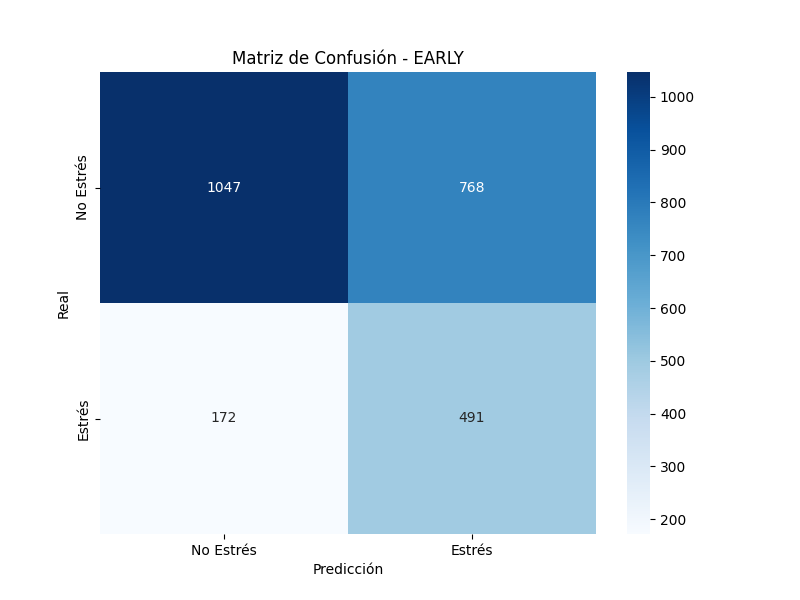

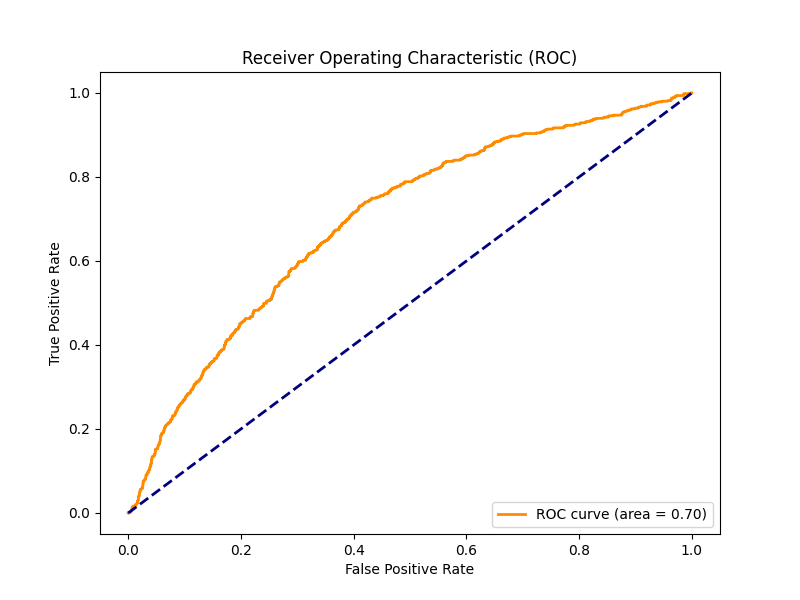

In [6]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_audio_wav2vec_ventana11_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--audio wav2vec "
        f"--audio_len 11 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_AUDIO_wav2vec_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_AUDIO_wav2vec_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* `MFCCs + RMS + ZCR`

100%|██████████| 2478/2478 [00:11<00:00, 221.56it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 1,414,145
Parámetros Entrenables: 1,414,145
Tiempo medio de Inferencia: 3.24 ms / muestra
ROC-AUC Score: 0.4882
F1 Macro: 0.4501
F1 Weighted: 0.6266
Accuracy (en %): 71.23%
Balanced Accuracy (en %): 49.91%


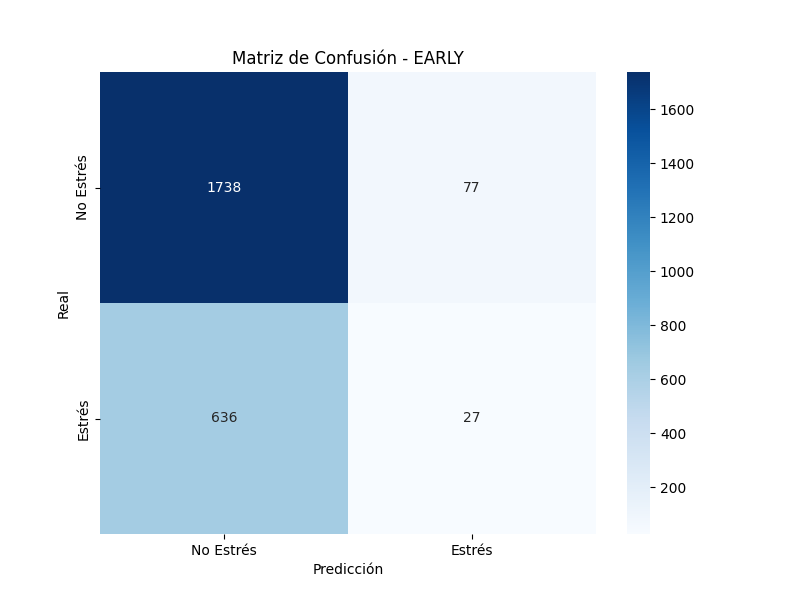

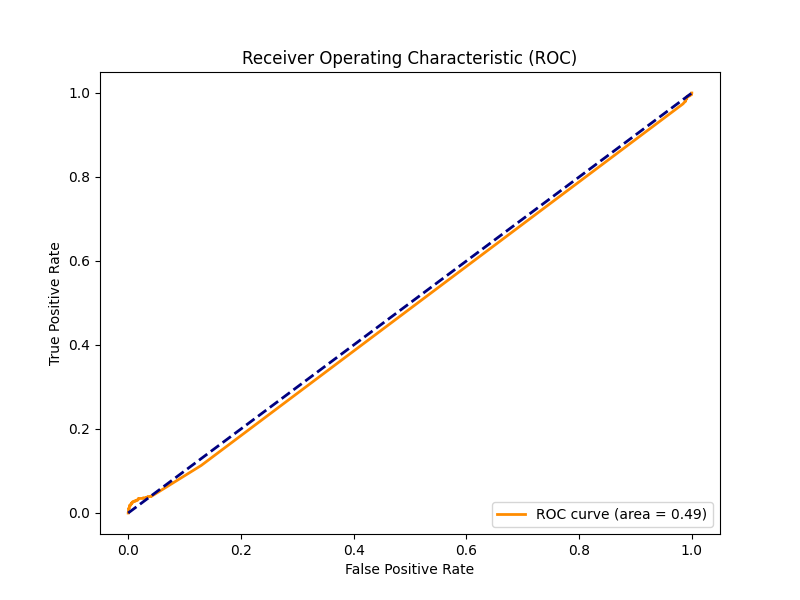

In [7]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_audio_mfcc_ventana11_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--audio mfcc "
        f"--audio_len 11 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_AUDIO_mfcc_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_AUDIO_mfcc_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **CODIFICADORES TEXTUALES** (Ventanas fijadas de 64 tokens):
* `BERT`

100%|██████████| 2478/2478 [00:01<00:00, 1516.13it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 460,801
Parámetros Entrenables: 460,801
Tiempo medio de Inferencia: 0.23 ms / muestra
ROC-AUC Score: 0.8206
F1 Macro: 0.7051
F1 Weighted: 0.7518
Accuracy (en %): 73.93%
Balanced Accuracy (en %): 74.11%


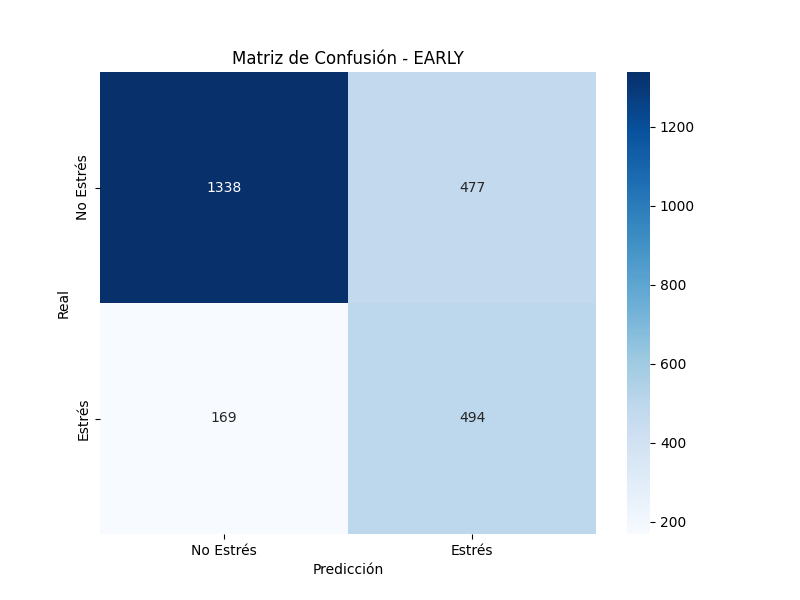

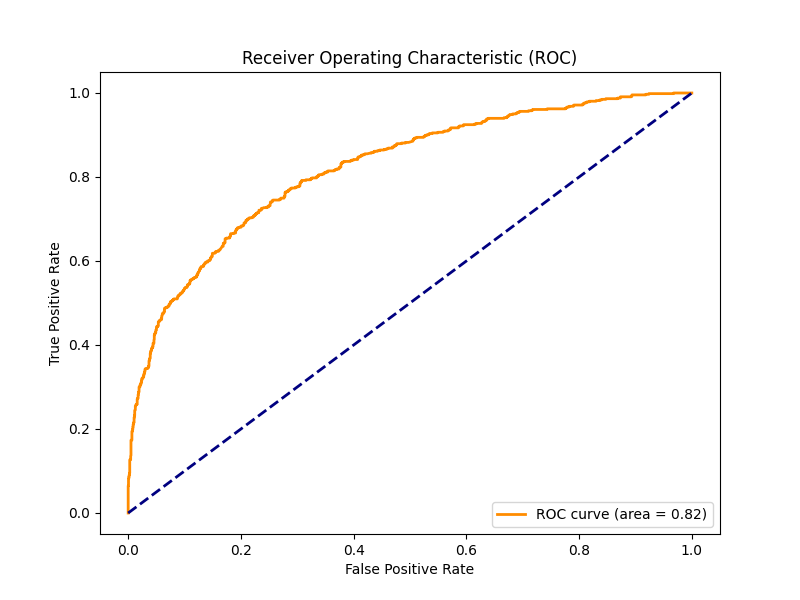

In [8]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_texto_bert64_ventana64_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--text bert64 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_TEXTO_bert64_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_TEXTO_bert64_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* `RoBERTa`

100%|██████████| 2478/2478 [00:01<00:00, 1690.91it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 460,801
Parámetros Entrenables: 460,801
Tiempo medio de Inferencia: 0.20 ms / muestra
ROC-AUC Score: 0.8212
F1 Macro: 0.7321
F1 Weighted: 0.7922
Accuracy (en %): 79.46%
Balanced Accuracy (en %): 72.72%


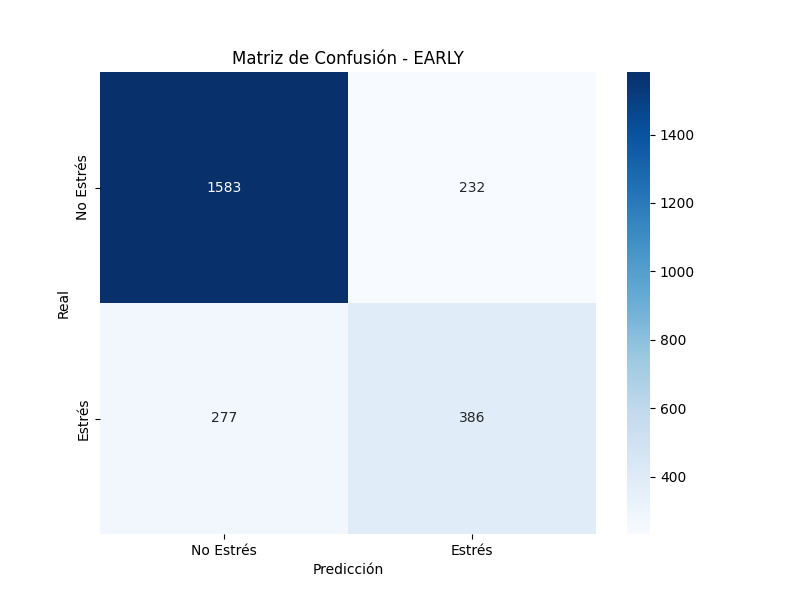

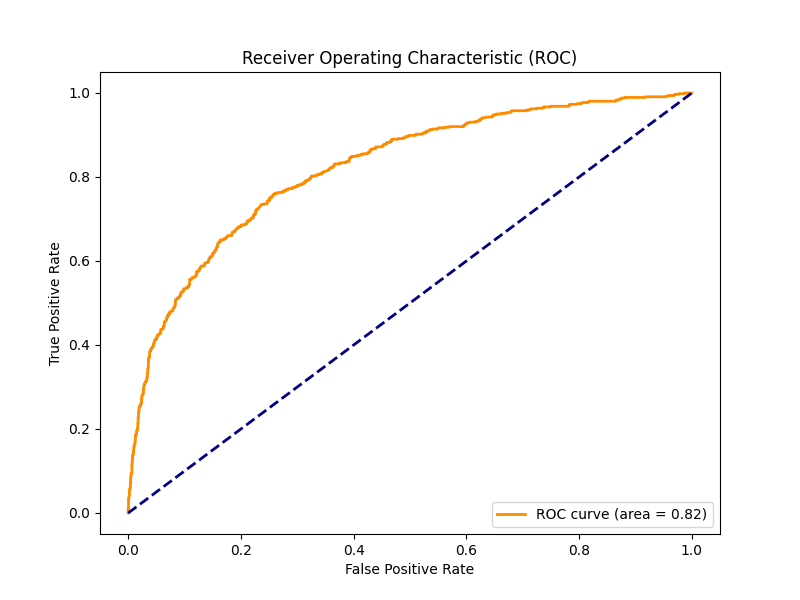

In [9]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_texto_roberta64_ventana64_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--text roberta64 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_TEXTO_roberta64_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_TEXTO_roberta64_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* `DeBERTa`

100%|██████████| 2478/2478 [00:01<00:00, 1733.46it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 460,801
Parámetros Entrenables: 460,801
Tiempo medio de Inferencia: 0.20 ms / muestra
ROC-AUC Score: 0.7703
F1 Macro: 0.6732
F1 Weighted: 0.7281
Accuracy (en %): 71.59%
Balanced Accuracy (en %): 69.88%


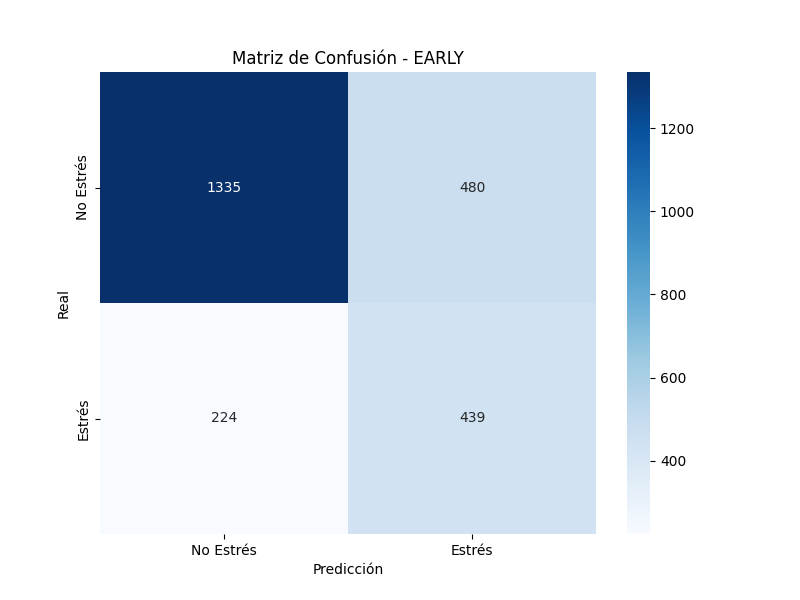

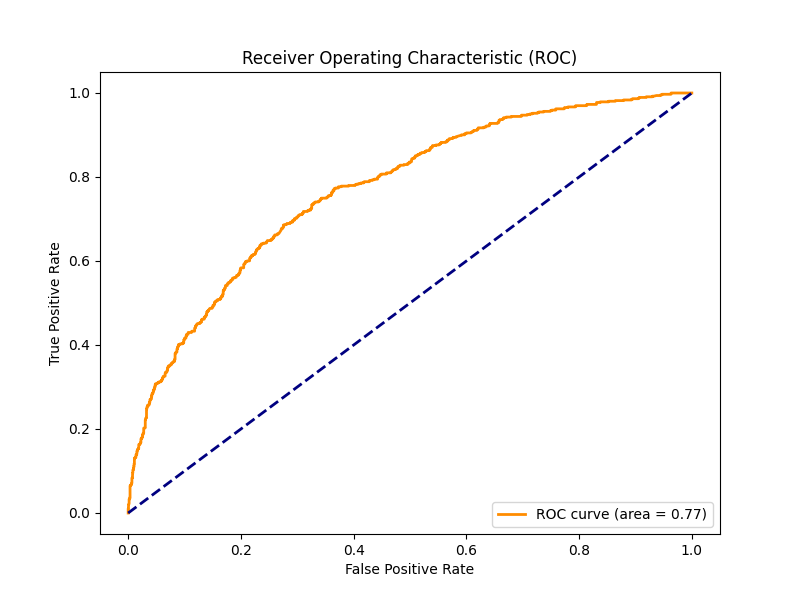

In [10]:
path_pesos = "pesos/unimodales_sin_ajustar/pesos_baseline_unimodal_texto_deberta64_ventana64_pdim512_hmlp128_do0.5_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split dev "
        f"--text deberta64 "
    )

_ = subprocess.run(comando, shell=True)


nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_TEXTO_deberta64_dev.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_TEXTO_deberta64_dev.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

**Tabla comparativa con los resultados en validación de los 8 *baselines* unimodales**:

En la tabla se reflejan las 4 métricas principales (**F1-Score Macro**, **Balanced Accuracy**, **ROC-AUC**, **Recall (estrés)**) para cada uno de los modelos:

* **Esta se utilizará para la comparación con las arquitecturas de fusión temprana con hiperparámetros estándar fijados para seleccionar los extractores de características**:

In [ ]:
def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, Balanced Accuracy, el ROC-AUC y el Recall de la clase 'Estrés'.
    """
    f1_macro = 0.0
    auc = 0.0
    ba = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "Balanced Accuracy" in linea:
            ba = float(linea.split(":")[1].strip())
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, ba, auc, recall_estres

In [12]:
# Definimos los 8 modelos base, su modalidad, ventana y la ruta de su txt:
rutas_baselines = [
    # VÍDEO (32 frames)
    {'Modelo': 'ResNet', 'Modalidad': 'Vídeo', 'Ventana': '32 frames', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_VIDEO_resnet_dev.txt'},
    {'Modelo': 'ViT', 'Modalidad': 'Vídeo', 'Ventana': '32 frames', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_VIDEO_vit_dev.txt'},
    {'Modelo': 'EfficientNet', 'Modalidad': 'Vídeo', 'Ventana': '32 frames', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_VIDEO_efficientnet_dev.txt'},
    
    # AUDIO (11 segundos)
    {'Modelo': 'Wav2Vec 2.0', 'Modalidad': 'Audio', 'Ventana': '11 seg', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_AUDIO_wav2vec_dev.txt'},
    {'Modelo': 'MFCCs (+ RMS + ZCR)', 'Modalidad': 'Audio', 'Ventana': '11 seg', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_AUDIO_mfcc_dev.txt'},
    
    # TEXTO (64 tokens)
    {'Modelo': 'RoBERTa', 'Modalidad': 'Texto', 'Ventana': '64 tokens', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_TEXTO_roberta64_dev.txt'},
    {'Modelo': 'BERT', 'Modalidad': 'Texto', 'Ventana': '64 tokens', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_TEXTO_bert64_dev.txt'},
    {'Modelo': 'DeBERTa', 'Modalidad': 'Texto', 'Ventana': '64 tokens', 
     'Ruta': 'resultados/unimodales/dev/reporte_final_baseline_unimodal_TEXTO_deberta64_dev.txt'}
]

datos_baselines = []
for item in rutas_baselines:
    f1, ba, auc, recall = extraer_metricas_txt(item['Ruta'])
    datos_baselines.append({
        'Modalidad': item['Modalidad'],
        'Modelo': item['Modelo'],
        'Ventana': item['Ventana'],
        'F1_Macro': f1,
        'Balanced_Accuracy': ba,
        'AUC': auc,
        'Recall_Estres': recall
    })

# Creamos el DataFrame y lo ordenamos por Modalidad y luego por F1:
df_baselines = pd.DataFrame(datos_baselines).sort_values(by='F1_Macro', ascending=False)

# Lo guardamos como CSV:
df_baselines.to_csv("tabla_baselines_unimodales_dev.csv", index=False)

# Mostramos en pantalla
print("TABLA: BASELINES UNIMODALES")
display(df_baselines.style.background_gradient(subset=['F1_Macro', 'Balanced_Accuracy', 'AUC', 'Recall_Estres'], cmap='Blues').format(precision=4))

TABLA: BASELINES UNIMODALES


,Modalidad,Modelo,Ventana,F1_Macro,Balanced_Accuracy,AUC,Recall_Estres
5,Texto,RoBERTa,64 tokens,0.7321,0.7272,0.8212,0.5822
6,Texto,BERT,64 tokens,0.7051,0.7411,0.8206,0.7451
7,Texto,DeBERTa,64 tokens,0.6732,0.6988,0.7703,0.6621
3,Audio,Wav2Vec 2.0,11 seg,0.6006,0.6587,0.6964,0.7406
2,Vídeo,EfficientNet,32 frames,0.5715,0.6003,0.6121,0.5792
0,Vídeo,ResNet,32 frames,0.5658,0.6108,0.6131,0.6531
1,Vídeo,ViT,32 frames,0.5402,0.6060,0.6130,0.7195
4,Audio,MFCCs (+ RMS + ZCR),11 seg,0.4501,0.4991,0.4882,0.0407


Se observa que los extractores textuales alcanzan el mayor rendimiento sobre el corpus global, siendo **RoBERTa** el que mayor F1-Score Macro y ROC-AUC alcanza en validación. Por tanto, la modalidad textual podríamos pensar en un primer momento que será la más relevante para la tarea, ya que los modelos unimodales textuales, por ellos mismos, ya alcanzan buen rendimiento. En el otro extremo del ranking, a los que más les cuesta lograr un buen rendimiento para la tarea de detección de estrés sobre este dataset desbalanceado, son los codificadores visuales y acústicos, y, específicamente, el que peor rendimiento obtiene en las cuatro métricas es **MFCCs**. En base a esto, podemos pensar que las modalidades acústica y visual podrían no ser tan importantes o tener un menor peso a la hora de la tarea de detección por parte de nuestros modelos multimodales posteriores. Pero, todo esto debe confirmarse tras observar el rendimiento conjunto que alcanzan los extractores.

----

Estos resultados obtenidos en la partición de validación (**dev**) se tendrán en cuenta para la selección de los extractores de características en el próximo notebook, con el objetivo de evitar la explosión de hiperparámetros. 

---

